In [1]:
import os
import os.path as op
import numpy as np
import pandas as pd

bids_folder= '/mnt_01/ds-stressrisk' #'/shares/zne.uzh/mrenke/ds-stressrisk'
subject_list = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 6]
all_subjects_set = set(subject_list)
sub_array= np.array([int(i) for i in subject_list]) 

group_mapping = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))[['subject','group']].set_index('subject')

import nibabel as nb

surf_mask_R = op.join(bids_folder, 'derivatives/surface_masks', 'desc-NPC_R_space-fsaverage5_hemi-rh.label.gii')
surf_mask_R = nb.load(surf_mask_R).agg_data().astype(bool)

In [2]:
sub_array.sort()
sub_array

array([ 1,  2,  3,  4,  5,  9, 10, 12, 13, 14, 16, 17, 18, 19, 21, 22, 23,
       24, 25, 26, 28, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 59, 61])

In [3]:
from nipype.interfaces.freesurfer import SurfaceTransform

def transform_fsaverage5(in_file, fs_hemi, source_subject, bids_folder):

    subjects_dir = op.join(bids_folder, 'derivatives', 'freesurfer')

    sxfm = SurfaceTransform(subjects_dir=subjects_dir)
    sxfm.inputs.source_file = in_file
    sxfm.inputs.out_file = in_file.replace('fsnative', 'fsaverage5')
    sxfm.inputs.source_subject = source_subject
    sxfm.inputs.target_subject = 'fsaverage5'
    sxfm.inputs.hemi = fs_hemi

    r = sxfm.run()

In [ ]:
# sciencecloud !
from nilearn import surface
import nibabel as nb
from stress_risk.utils.data import Subject

key = 'encoding_model.model6.retroicor'
param = 'r2'

errors = []
for sub in subject_list:
    try:
        target_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func')
        ex_file = op.join(target_dir, f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-R.func.gii')
        if not op.exists(ex_file):
            os.makedirs(target_dir, exist_ok=True)
            subject = Subject(int(sub), bids_folder=bids_folder)

            surfinfo = subject.get_surf_info_fs()
            prf_pars_volume = op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.nii.gz')
            print(f'Writing to {target_dir}')

            for hemi in ['L', 'R']:
                samples = surface.vol_to_surf(prf_pars_volume, surfinfo[hemi]['outer'], inner_mesh=surfinfo[hemi]['inner'])
                fs_hemi = 'lh' if hemi == 'L' else 'rh'

                im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(samples)])
                target_fn =  op.join(target_dir, f'sub-{sub}_desc-{param}.optim.nilearn_space-fsnative_hemi-{hemi}.func.gii')
                nb.save(im, target_fn)

                transform_fsaverage5(target_fn, fs_hemi, f'sub-{sub}', bids_folder)
            print(f'Success for {sub}')
    except:
        print(f'Failed for {sub}')
        errors.append(sub)

In [ ]:
# normal nPRF ses1/2 

key = 'encoding_model.denoise.retroicor'
param = 'r2'
ses = 2
errors = []

for sub in subject_list:
    try:
        target_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', f'ses-{ses}', 'func')
        ex_file = op.join(target_dir, f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-R.func.gii')
        if not op.exists(ex_file):
            os.makedirs(target_dir, exist_ok=True)
            subject = Subject(int(sub), bids_folder=bids_folder)

            surfinfo = subject.get_surf_info_fs()
            prf_pars_volume = op.join(target_dir, f'sub-{sub}_ses-{ses}_desc-{param}.optim_space-T1w_pars.nii.gz')
            print(f'Writing to {target_dir}')

            for hemi in ['L', 'R']:
                samples = surface.vol_to_surf(prf_pars_volume, surfinfo[hemi]['outer'], inner_mesh=surfinfo[hemi]['inner'])
                fs_hemi = 'lh' if hemi == 'L' else 'rh'

                im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(samples)])
                target_fn =  op.join(target_dir, f'sub-{sub}_ses-{ses}_desc-{param}.optim.nilearn_space-fsnative_hemi-{hemi}.func.gii')
                nb.save(im, target_fn)

                transform_fsaverage5(target_fn, fs_hemi, f'sub-{sub}', bids_folder)
            print(f'Success for {sub}')
    except:
        print(f'Failed for {sub}')
        errors.append(sub)


In [20]:
sub = '48'
hemi = 'R'
param = 'r2'

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_ses1 = nb.load(fn).agg_data()[surf_mask_R]

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_ses2 = nb.load(fn).agg_data()[surf_mask_R]

fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_reg = nb.load(fn).agg_data()[surf_mask_R]




In [36]:
from scipy.stats import pearsonr
import itertools

r2_correlations = []
errors = []

for sub in subject_list:
    try: 
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
        npc_ses1 = nb.load(fn).agg_data()[surf_mask_R]

        fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
        npc_ses2 = nb.load(fn).agg_data()[surf_mask_R]

        fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
        npc_reg = nb.load(fn).agg_data()[surf_mask_R]

        df = pd.DataFrame({'ses1':npc_ses1, 'ses2':npc_ses2, 'reg':npc_reg})
        for comb in itertools.combinations(df.columns, 2):
            corcoef, pval = pearsonr(df[comb[0]], df[comb[1]])
            r2_correlations.append({'sub':sub, 'comb':comb, 'corcoef':corcoef, 'pval':pval})
    except:
        print(f'Failed for {sub}')
        errors.append(sub)



Failed for 13
Failed for 32


In [ ]:
# threshold?!
(npc_ses1 > 0.05).sum()

65

In [57]:
df = pd.DataFrame(r2_correlations).set_index(['sub','comb'])
df['pval_transformed'] = -np.log10(df['pval'])

df.head()

corcoef          pval  pval_transformed
sub comb                                                  
12  (ses1, ses2) -0.140944  5.174177e-05          4.286159
    (ses1, reg)   0.255240  1.202226e-13         12.920014
    (ses2, reg)   0.073147  3.635494e-02          1.439437
17  (ses1, ses2)  0.254440  1.440981e-13         12.841342
    (ses1, reg)   0.096478  5.722743e-03          2.242396

In [66]:
df[df['corcoef'].max() == df['corcoef']]

,,corcoef,pval,pval_transformed
sub,comb,,,
19,"(ses1, ses2)",0.808485,2.696091e-190,189.569265


Text(0.5, 0.98, 'Correlation between different nPRF r2 over vertices (mean per subject) | hemi-R')

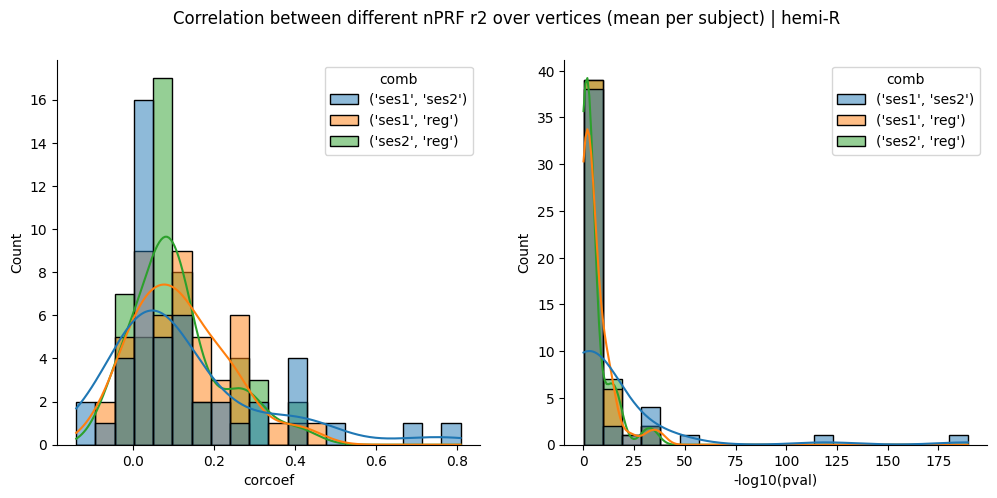

In [61]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df.reset_index(), x='corcoef', hue='comb', bins=20, kde=True, ax=axs[0])
sns.histplot(df.reset_index(), x='pval_transformed', hue='comb', bins=20, kde=True, ax=axs[1])

axs[1].set(xlabel='-log10(pval)')
sns.despine()
fig.suptitle('Correlation between different nPRF r2 over vertices (mean per subject) | hemi-R')


Text(0.5, 0.98, 'sub: 22')

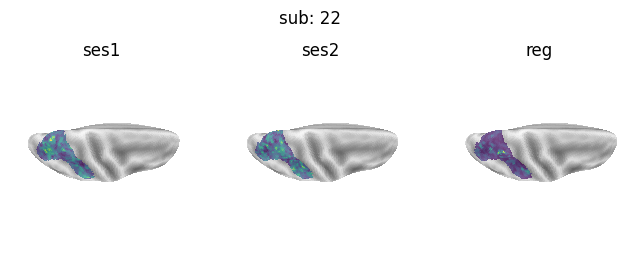

In [ ]:
import nilearn.plotting as nplt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

sub = '22' # 19 best in terms of consistency over models    
hemi = 'R'
view = 'dorsal'

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_ses1 = nb.load(fn).agg_data()
fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_ses2 = nb.load(fn).agg_data()
fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
npc_reg = nb.load(fn).agg_data()

figure, axes = plt.subplots(nrows=1, ncols=3,figsize = (8,3), subplot_kw=dict(projection='3d'))
for i, model in enumerate([npc_ses1, npc_ses2, npc_reg]):
    map = model
    map[~surf_mask_R] = np.nan
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= map, # infl_right # pial_right cmap=cmap_two, 
        view=view,colorbar=False, axes=axes[i],
        bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7) #
    axes[i].set_title(f'{["ses1", "ses2", "reg"][i]}')

figure.suptitle(f'sub: {sub}')


# Look at Mus

but in Volume space to keep things a bit more simple!



In [2]:
from stress_risk.utils.data import Subject
from nilearn.maskers import NiftiMasker
from nilearn import image

def get_vselect_mask(sub, bids_folder):
    roi='NPC_R'
    source_key_vselect = 'encoding_model.cv.denoise.retroicor'
    session1 = 1
    subject = Subject(int(sub), bids_folder=bids_folder)
    ips_mask = subject.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    ips_masker = NiftiMasker(mask_img=ips_mask)
    im_cvr2_fn = op.join(bids_folder, 'derivatives', source_key_vselect, f'sub-{sub}', f'ses-{session1}','func', f'sub-{sub}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(im_cvr2_fn)
    cv_r2 = pd.DataFrame(ips_masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().flatten()
    print(f'Number of voxels: {r2_mask.sum()}')
    return r2_mask, ips_masker

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/tqdm-4.64.1-py3.10.egg/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
sub = '01'
param = 'mu'
space = 'T1w'

vselect_mask, ips_masker = get_vselect_mask(sub, bids_folder)

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim_space-{space}_pars.nii.gz')
npc_ses1 = ips_masker.fit_transform(fn).flatten()#nb.load(fn).get_fdata().flatten()

fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim_space-{space}_pars.nii.gz')
npc_ses2 = ips_masker.fit_transform(fn).flatten()

fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-{space}_pars.nii.gz')
npc_reg_ses1 = ips_masker.fit_transform(fn).flatten()

fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-{space}_pars.nii.gz')
npc_reg_ses2 = ips_masker.fit_transform(fn).flatten()

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/image/resampling.py:684: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 43


In [22]:
subject = Subject(int(sub), bids_folder=bids_folder)

pars1 = subject.get_prf_parameters_volume(session=1, cross_validated=False,denoise=True, retroicor=True,smoothed=False, pca_confounds=False,roi='NPC_R')
pars1.head()

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/image/resampling.py:684: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


parameter,mu,sd,amplitude,baseline
0,4.234713,0.069689,2.828103,-0.289795
1,2.881828,3.464420,8.321482,-7.916214
2,3.109055,0.283462,0.324707,-0.158504
3,3.362120,3.426072,5.164534,-4.942795
4,4.831793,0.456263,1.720093,0.084141


In [24]:
pars_s = pars1
pars_s['mu'] = np.exp(pars_s['mu']) # mode
pars_s.head()


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


parameter,mu,sd,amplitude,baseline
0,9.649464e+29,0.069689,2.828103,-0.289795
1,5.633757e+07,3.464420,8.321482,-7.916214
2,5.347325e+09,0.283462,0.324707,-0.158504
3,3.384700e+12,3.426072,5.164534,-4.942795
4,inf,0.456263,1.720093,0.084141


In [19]:
df = pd.DataFrame({'ses1':npc_ses1, 'ses2':npc_ses2, 
                    'reg_ses1':npc_reg_ses1, 'reg_ses2':npc_reg_ses2,  
                    'voxel_n':np.arange(len(npc_ses1)), 'subject':int(sub)})
df.head()

,ses1,ses2,reg_ses1,reg_ses2,voxel_n,subject
0,4.234713,2.536406,49.630119,17.272280,0,1
1,2.881828,0.201451,22.588398,42.925011,1,1
2,3.109055,3.850733,30.162977,43.865295,2,1
3,3.362120,1.530222,7.143418,31.812082,3,1
4,4.831793,2.206294,5.851123,31.817196,4,1


In [ ]:
data = []
errors = []
for sub in subject_list:
    try:
        vselect_mask, ips_masker = get_vselect_mask(sub, bids_folder)
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim_space-{space}_pars.nii.gz')
        npc_ses1 = ips_masker.fit_transform(fn).flatten()
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim_space-{space}_pars.nii.gz')
        npc_ses2 = ips_masker.fit_transform(fn).flatten()
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-{space}_pars.nii.gz')
        npc_reg_ses1 = ips_masker.fit_transform(fn).flatten()
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-{space}_pars.nii.gz')
        npc_reg_ses2 = ips_masker.fit_transform(fn).flatten()
        data.append(pd.DataFrame({'ses1':npc_ses1, 'ses2':npc_ses2, 
                    'reg_ses1':npc_reg_ses1, 'reg_ses2':npc_reg_ses2,  
                    'voxel_n':np.arange(len(npc_ses1)), 'subject':int(sub)}))
    except:
        print(f'Failed for {sub}')
        errors.append(sub)  
print(errors)

In [40]:
df = pd.concat(data, ignore_index=True).set_index(['subject','voxel_n'])
df['ses1'] = np.exp(df['ses1'])
df['ses2'] = np.exp(df['ses2'])
df.head()

ses1       ses2   reg_ses1   reg_ses2
subject voxel_n                                            
12      0         4.344145  10.834392   0.000000   0.000000
        1         4.975430  49.266632  32.174973  12.175588
        2         8.192156  48.288429   0.000000   0.000000
        3        16.166029  49.682793   0.000000   0.000000
        4         9.484070  21.416262  22.165333  10.691992

In [43]:
df.xs(sub, level='subject').mean()

ses1        103.471397
ses2         68.322395
reg_ses1     20.790009
reg_ses2     24.358494
dtype: float32

In [46]:
vselect_mask, ips_masker = get_vselect_mask(sub, bids_folder)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/image/resampling.py:684: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 120


In [48]:
vselect_mask.shape

(1164,)

In [49]:
tmp.loc[vselect_mask]

,ses1,ses2,reg_ses1,reg_ses2
voxel_n,,,,
43,14.738738,7.827851,19.438307,52.785961
45,7.160562,17.546175,31.467434,15.470777
64,6.238968,4.201614,42.333332,37.000000
74,10.781418,12.588248,14.109609,54.317402
76,21.066442,14.396241,23.701204,29.819654
...,...,...,...,...
1078,14.415146,13.578194,5.731812,27.077475
1092,14.449610,15.011251,-0.721148,-0.420286
1094,14.581109,15.315289,-0.070568,-0.487593


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/image/resampling.py:684: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 35


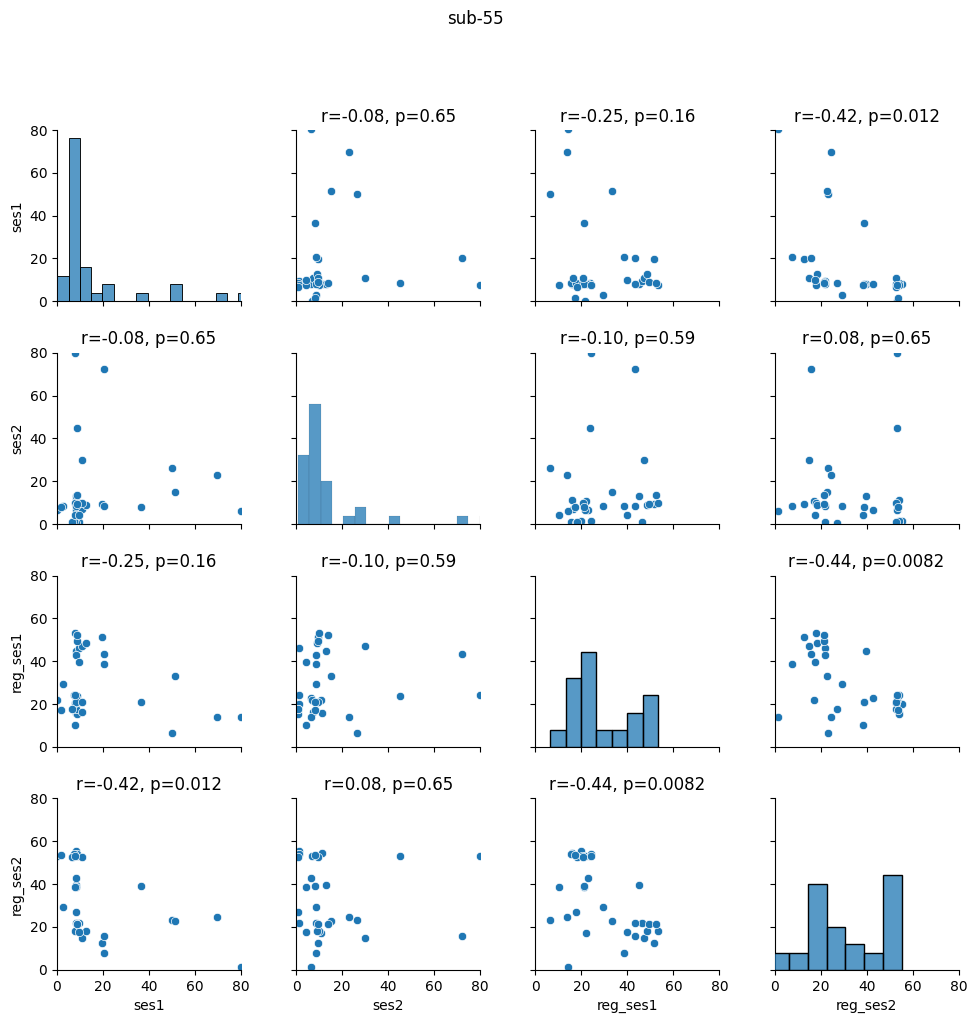

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sub = 55 # sub-1 is weird.... but e.g. 12 looks better
vselect_mask, ips_masker = get_vselect_mask(sub, bids_folder)

tmp = df.xs(sub, level='subject').loc[vselect_mask]
grid = sns.pairplot(tmp, )
x_limits = (0, 80)
y_limits = (0, 80)

# Iterate over each subplot and calculate the correlation coefficient and p-value
for i, row in enumerate(grid.axes):
    for j, ax in enumerate(row):
        if i != j:  # Skip the diagonal plots
            x = tmp.iloc[:, j]
            y = tmp.iloc[:, i]
            corr, p_value = pearsonr(x, y)
            ax.set_title(f'r={corr:.2f}, p={p_value:.2g}')
            ax.set_xlim(x_limits)
            ax.set_ylim(y_limits)

plt.suptitle(f'sub-{sub}', y=1.02)
plt.subplots_adjust(top=0.9,wspace=0.3, hspace=0.3)


In [ ]:
# regression MUs correlated between sessions

In [ ]:
from scipy.stats import pearsonr
import itertools

r2_correlations = []
errors = []

for sub in subject_list:
    try: 
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-1','func', f'sub-{sub}_ses-1_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
        npc_ses1 = nb.load(fn).agg_data()[surf_mask_R]

        fn = op.join(bids_folder, 'derivatives', 'encoding_model.denoise.retroicor', f'sub-{sub}', f'ses-2','func', f'sub-{sub}_ses-2_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
        npc_ses2 = nb.load(fn).agg_data()[surf_mask_R]

        fn = op.join(bids_folder, 'derivatives', 'encoding_model.model6.retroicor', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim.nilearn_space-fsaverage5_hemi-{hemi}.func.gii')
        npc_reg = nb.load(fn).agg_data()[surf_mask_R]

        df = pd.DataFrame({'ses1':npc_ses1, 'ses2':npc_ses2, 'reg':npc_reg})
        for comb in itertools.combinations(df.columns, 2):
            corcoef, pval = pearsonr(df[comb[0]], df[comb[1]])
            r2_correlations.append({'sub':sub, 'comb':comb, 'corcoef':corcoef, 'pval':pval})
    except:
        print(f'Failed for {sub}')
        errors.append(sub)

